# Pandas Practice 2

![IRIS, https://github.com/simonava5/fishers-iris-data](./images/iris.png)

After the notebook with a lot of new input, let's start applying it totally by yourselves. 
For this purpose we will use one of the most standard real-life datasets: Its called Iris Dataset, and is all about the plant iris. Let's learn a little bit more about the dataset by looking at it. 

## Learning Objectives





By the end of this notebook, you will feel more comfortable with your newly acquired knowledge, as you will see that you can

- load data from csv files into DataFrames
- access data stored in DataFrames
- use the general functions of a DataFrame to answer questions about the data
- create insightful plots using the pandas function `.plot()`
- explain what conclusions you draw from these visualizations.


In [1]:
# import pandas
import pandas as pd

In [3]:
# load the data
df = pd.read_csv('/Users/orontavor/Desktop/bootcamp/de-week-1-Python/05_pandas_intro/data/iris.csv')

Let us first have a look at the head of the table, maybe also on the last 10 rows...

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [6]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


How many irises are in the data set?

In [8]:
len(df[df['species'].str.contains('Iris')])

150

How many different species are there?

In [9]:
#select distinct species from table
df['species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

Calculate the mean, median, mode for petal length

In [ ]:
df['petal_length'].mean()

0    1.5
Name: petal_length, dtype: float64

In [11]:
df['petal_length'].median()

np.float64(4.35)

In [12]:
df['petal_length'].mode()

0    1.5
Name: petal_length, dtype: float64

What can you conclude about the distribution for petal length?

In [ ]:
# some petals are short on length, since the avg is skewed down compared to the median

What is the smallest and largest value for petal length?

In [15]:
# select min(petal_length) as min_length, max(petal_length) max_length
df['petal_length'].agg(['min', 'max'])

min    1.0
max    6.9
Name: petal_length, dtype: float64

Calculate the variance and standard deviation for petal length

In [ ]:
#standard deviation
df['petal_length'].std()

np.float64(1.7644204199522626)

In [17]:
#variance
df['petal_length'].var()

np.float64(3.113179418344519)

Calculate the basic descriptive statistics for all columns of the iris data set with a single command.

In [18]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


What is the overall average for sepal length?

In [19]:
df['sepal_length'].mean()

np.float64(5.843333333333334)

Use the DataFrame grouping function to determine the count by species.

In [21]:
#select species, count(*) from table group by 1
df.groupby('species').size().reset_index(name='count')

,species,count
0,Iris-setosa,50
1,Iris-versicolor,50
2,Iris-virginica,50


Use the DataFrame grouping function to determine the average length and width of sepals and pedals by species.

In [ ]:
# select species, avg(sepal_length), avg(sepal_width), avg(petal_length), avg(petal_width) from table group by 1
df.groupby('species')[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].mean()

Add the sum of the sepal width and length as a new column to your DataFrame.

In [22]:
# SELECT *, (sepal_width + sepal_length) AS sep_size
df['sep_size'] = df['sepal_width'] + df['sepal_length']

In [23]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sep_size
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6


Visualize petal length with a histogram

<Axes: >

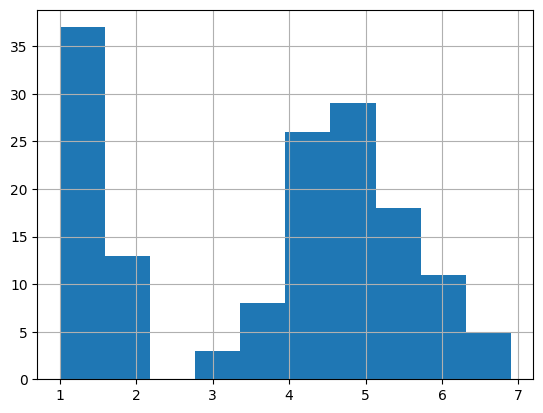

In [24]:
df['petal_length'].hist()

Describe the distribution

In [ ]:
#there a wide distribution of length

Which is more informative: the summary statistics or visualizations?

In [ ]:
#vizualizations

Visualize petal length and width with a "scatter_matrix"

Create a new column with a rough estimate of petal area by multiplying petal length and width together.

array([[<Axes: xlabel='petal_length', ylabel='petal_length'>,
        <Axes: xlabel='petal_width', ylabel='petal_length'>],
       [<Axes: xlabel='petal_length', ylabel='petal_width'>,
        <Axes: xlabel='petal_width', ylabel='petal_width'>]], dtype=object)

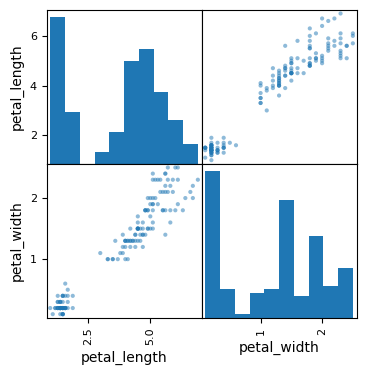

In [26]:
pd.plotting.scatter_matrix(df[['petal_length', 'petal_width']], figsize=(4,4))

Create a new DataFrame with petal areas greater than $1cm^2$.

In [27]:
df['petal_area'] = df['petal_length'] * df['petal_width']
new_df = df[df['petal_area'] > 1]

Create 3 new DataFrames, one for each species. Use the entire dataset.

In [30]:
large_flowers = df[(df['petal_length'] > 5)]

In [32]:
wide_petals = df[df['petal_width'] > df['petal_width'].median()]

In [33]:
small_sepals = df[df['sepal_length'] < 5]